# Linear Algebra Assignment

### Question 1
Using auto-mpg data, find the top 5 similar cars to toyota corona mark ii

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("auto-mpg.csv")

df = df.replace("?", np.nan).dropna()

num_cols = [
    "mpg", "cylinders", "displacement",
    "horsepower", "weight", "acceleration", "model year"
]
df[num_cols] = df[num_cols].astype(float)


X = df[num_cols].values
car_names = df["car name"].str.lower().values

target_car = "toyota corona mark ii"
target_idx = np.where(car_names == target_car)[0][0]
target_vector = X[target_idx]

msv_scores = []
for i in range(len(X)):
    diff = X[i] - target_vector
    msv = np.mean(diff ** 2)
    msv_scores.append((i, msv))

msv_scores = sorted(msv_scores, key=lambda x: x[1])[1:6]

result = pd.DataFrame({
    "Car Name": [df.iloc[i]["car name"] for i, _ in msv_scores],
    "Mean Square Value": [round(score, 2) for _, score in msv_scores]
})

print(result)


                    Car Name  Mean Square Value
0                 datsun 610              12.89
1                   saab 99e              13.89
2                     subaru              58.61
3            ford pinto (sw)             100.00
4  chevrolet cavalier 2-door             118.86


## Using Cosine

In [60]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

df = pd.read_csv("auto-mpg.csv")

df = df.replace("?", np.nan)
df.dropna(inplace=True)

num_cols = [
    "mpg", "cylinders", "displacement",
    "horsepower", "weight", "acceleration", "model year"
]
df[num_cols] = df[num_cols].astype(float)

X = df[num_cols]
car_names = df["car name"].str.lower()

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

similarity_matrix = cosine_similarity(X_scaled)

target_car = "toyota corona mark ii"
target_idx = car_names[car_names == target_car].index[0]

scores = list(enumerate(similarity_matrix[target_idx]))

scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:6]

result = pd.DataFrame({
    "Car Name": [df.iloc[i]["car name"] for i, _ in scores],
    "Similarity Score": [round(score, 4) for _, score in scores]
})

print(result)


                      Car Name  Similarity Score
0                  audi 100 ls            0.9940
1                 datsun pl510            0.9756
2  toyouta corona mark ii (sw)            0.9749
3                toyota corona            0.9724
4        toyota corona hardtop            0.9709


### Question 2
Find completely unique/orthogonal car to toyota corona mark ii

In [64]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Load dataset
df = pd.read_csv("auto-mpg.csv")

# Clean data
df = df.replace("?", np.nan).dropna()

# Numeric columns
num_cols = [
    "mpg", "cylinders", "displacement",
    "horsepower", "weight", "acceleration", "model year"
]
df[num_cols] = df[num_cols].astype(float)

# Feature matrix and car names
X = df[num_cols].values
car_names = df["car name"].str.lower().values

# Cosine similarity (no scaling)
cos_sim = cosine_similarity(X)

# Target car
target_car = "toyota corona mark ii"
target_idx = np.where(car_names == target_car)[0][0]

# Compute theta values
theta_scores = []
for i, sim in enumerate(cos_sim[target_idx]):
    if i == target_idx:
        continue
    theta = np.degrees(np.arccos(np.clip(sim, -1.0, 1.0)))
    theta_scores.append((i, theta))

# Find theta closest to 90°
orthogonal_idx, orthogonal_theta = min(
    theta_scores, key=lambda x: abs(x[1] - 90)
)

# Output
print("Most orthogonal car:", df.iloc[orthogonal_idx]["car name"])
print("Theta (degrees):", round(orthogonal_theta, 2))

Most orthogonal car: buick estate wagon (sw)
Theta (degrees): 5.96


### Question 3
Project the data to a 2-dimentional space and visualize using scatter plot

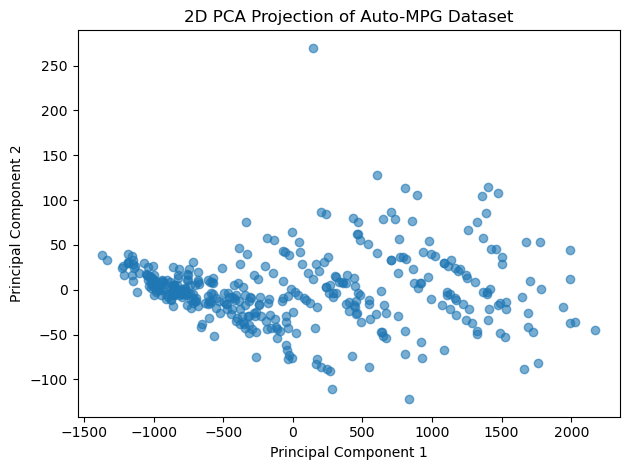

In [70]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


df = pd.read_csv("auto-mpg.csv")

df = df.replace("?", np.nan).dropna()

num_cols = [
    "mpg", "cylinders", "displacement",
    "horsepower", "weight", "acceleration", "model year"
]
df[num_cols] = df[num_cols].astype(float)

X = df[num_cols].values
car_names = df["car name"].str.lower().values


# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)

# Project to 2D using PCA
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)


plt.figure()
plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.6)
 
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("2D PCA Projection of Auto-MPG Dataset")
plt.tight_layout()
plt.show()


In [72]:
def dot_product(a, b):
    if len(a) != len(b):
        raise ValueError("Lists must have the same length")
    return sum(x * y for x, y in zip(a, b))


In [74]:
v1 = [1, 2, 3]
v2 = [4, 5, 6]

print(dot_product(v1, v2)) 

32


### Question 5
Write a function that returns the projection of vector a onto vector b. Both a and b are given as list of numbers

In [76]:
import numpy as np

def projection_of_a_on_b(a, b):
    a = np.array(a, dtype=float)
    b = np.array(b, dtype=float)

    if np.all(b == 0):
        raise ValueError("Cannot project onto the zero vector")

    return (np.dot(a, b) / np.dot(b, b)) * b


In [78]:
a = [3, 4]
b = [1, 2]

proj = projection_of_a_on_b(a, b)
print(proj)


[2.2 4.4]


### Question 6
Create a class Vector that supports addition, dot product, and magnitude.

In [81]:
import math

class Vector:
    def __init__(self, values):
        if not values:
            raise ValueError("Vector cannot be empty")
        self.values = list(values)

    def __add__(self, other):
        if len(self.values) != len(other.values):
            raise ValueError("Vectors must have the same dimension")
        return Vector([a + b for a, b in zip(self.values, other.values)])

    def dot(self, other):
        if len(self.values) != len(other.values):
            raise ValueError("Vectors must have the same dimension")
        return sum(a * b for a, b in zip(self.values, other.values))

    def magnitude(self):
        return math.sqrt(sum(x ** 2 for x in self.values))

    def __repr__(self):
        return f"Vector({self.values})"


In [83]:
v1 = Vector([1, 2, 3])
v2 = Vector([4, 5, 6])

print(v1 + v2)          # Vector([5, 7, 9])
print(v1.dot(v2))       # 32
print(v1.magnitude())   # 3.7416573867739413


Vector([5, 7, 9])
32
3.7416573867739413


In [85]:
import numpy as np

class Vector:
    def __init__(self, values):
        self.data = np.array(values, dtype=float)
        if self.data.ndim != 1:
            raise ValueError("Vector must be one-dimensional")

    def __add__(self, other):
        if self.data.shape != other.data.shape:
            raise ValueError("Vectors must have the same dimension")
        return Vector(self.data + other.data)

    def dot(self, other):
        if self.data.shape != other.data.shape:
            raise ValueError("Vectors must have the same dimension")
        return float(np.dot(self.data, other.data))

    def magnitude(self):
        return float(np.linalg.norm(self.data))

    def __repr__(self):
        return f"Vector({self.data.tolist()})"


In [87]:
v1 = Vector([1, 2, 3])
v2 = Vector([4, 5, 6])

print(v1 + v2)        
print(v1.dot(v2))     
print(v1.magnitude()) 


Vector([5.0, 7.0, 9.0])
32.0
3.7416573867739413


### Question 7
Write a function that returns the L1 and L2 norms of a vector given as list

In [90]:
import numpy as np

def l1_l2_norms(v):
    v = np.array(v, dtype=float)

    if v.ndim != 1 or v.size == 0:
        raise ValueError("Input must be a non-empty 1D vector")

    l1 = np.linalg.norm(v, ord=1)   # L1 norm
    l2 = np.linalg.norm(v, ord=2)   # L2 norm (Euclidean)

    return l1, l2


In [94]:
v = [1, -2, 3]

l1, l2 = l1_l2_norms(v)
print(l1)
print(l2)


6.0
3.7416573867739413
